In [10]:
import pandas as pd
import geopandas as gpd

In [38]:
upl = gpd.read_file("upl.json")
hei = gpd.read_file("ies.geojson")

In [39]:
upl = upl[["OBJECTID", "CODIGO_UPL", "NOMBRE", "SECTOR", "geometry"]]

In [27]:
upl.head()

,OBJECTID,CODIGO_UPL,NOMBRE,SECTOR,geometry
0,1,UPL13,Tintal,Sector Sur Occidente,"POLYGON ((-74.16957 4.65632, -74.16955 4.65631..."
1,2,UPL30,Salitre,Sector Occidente,"POLYGON ((-74.09471 4.66478, -74.10058 4.65718..."
2,3,UPL22,Restrepo,Sector Centro Ampliado,"POLYGON ((-74.10459 4.56467, -74.10468 4.56482..."
3,4,UPL31,Puente Aranda,Sector Centro Ampliado,"POLYGON ((-74.0832 4.6247, -74.084 4.62371, -7..."
4,5,UPL32,Teusaquillo,Sector Centro Ampliado,"POLYGON ((-74.0716 4.61775, -74.07283 4.61542,..."


In [14]:
import os
import glob

files = glob.glob(os.path.join(".", "em*.csv"))

for file in files:
    file_name = os.path.basename(file)  
    df_name = file_name.removeprefix("em_").replace(".csv", "")
    globals()[df_name] = pd.read_csv(file, sep=";")
    print(f"df '{df_name}' created from '{file_name}' → {globals()[df_name].shape}")

df 'ingreso_por_hogar' created from 'em_ingreso_por_hogar.csv' → (33, 4)
df 'minutos_al_estudio' created from 'em_minutos_al_estudio.csv' → (33, 4)
df 'minutos_al_trabajo' created from 'em_minutos_al_trabajo.csv' → (33, 4)
df 'nivel_educativo' created from 'em_nivel_educativo.csv' → (33, 12)
df 'personas_segun_sexo' created from 'em_personas_segun_sexo.csv' → (33, 9)
df 'personas_segun_si_actualmente_estudian' created from 'em_personas_segun_si_actualmente_estudian.csv' → (33, 7)
df 'personas_segun_si_saben_leer_y_escribir' created from 'em_personas_segun_si_saben_leer_y_escribir.csv' → (33, 7)
df 'promedio_edad' created from 'em_promedio_edad.csv' → (33, 4)
df 'promedio_personas_hogar' created from 'em_promedio_personas_hogar.csv' → (33, 4)
df 'satisfaccion_con_barrio_comunidad' created from 'em_satisfaccion_con_barrio_comunidad.csv' → (33, 4)
df 'satisfaccion_con_ingresos' created from 'em_satisfaccion_con_ingresos.csv' → (33, 4)
df 'satisfaccion_con_la_vida' created from 'em_satisfa

In [28]:
columns_to_merge = {
    "ingreso_por_hogar": ["PROMEDIO"],
    "promedio_edad": ["PROMEDIO"],
    "promedio_personas_hogar": ["PROMEDIO"],
    "minutos_al_estudio": ["PROMEDIO"],
    # "personas_segun_sexo": ["PORCENTAJE_HOMBRE", "PORCENTAJE_MUJER", "PORCENTAJE_INTERSEXUAL"],
    "personas_segun_si_actualmente_estudian": ["PORCENTAJE_SI", "PORCENTAJE_NO"],
    "nivel_educativo": ["PORCENTAJE_TECNICO", "PORCENTAJE_TECNOLOGO", "PORCENTAJE_UNIVERSITARIO_COMPLETO"]
}

In [40]:
for df_name, columns in columns_to_merge.items():
    rename_map = {col: f"{df_name}_{col}".lower() for col in columns}
    upl = upl.merge(
        globals()[df_name][["CODIGO_UPL"] + columns].rename(columns=rename_map),
        on="CODIGO_UPL",
        how="left"
    )

In [41]:
upl.columns

Index(['OBJECTID', 'CODIGO_UPL', 'NOMBRE', 'SECTOR', 'geometry',
       'ingreso_por_hogar_promedio', 'promedio_edad_promedio',
       'promedio_personas_hogar_promedio', 'minutos_al_estudio_promedio',
       'personas_segun_si_actualmente_estudian_porcentaje_si',
       'personas_segun_si_actualmente_estudian_porcentaje_no',
       'nivel_educativo_porcentaje_tecnico',
       'nivel_educativo_porcentaje_tecnologo',
       'nivel_educativo_porcentaje_universitario_completo'],
      dtype='object')

In [42]:
upl[["ingreso_por_hogar_promedio",
    "nivel_educativo_porcentaje_tecnico", 
     "nivel_educativo_porcentaje_tecnologo",
     "nivel_educativo_porcentaje_universitario_completo"]].isnull().sum()

ingreso_por_hogar_promedio                           0
nivel_educativo_porcentaje_tecnico                   0
nivel_educativo_porcentaje_tecnologo                 0
nivel_educativo_porcentaje_universitario_completo    0
dtype: int64

In [43]:
upl.describe()

,OBJECTID,ingreso_por_hogar_promedio,promedio_edad_promedio,promedio_personas_hogar_promedio,minutos_al_estudio_promedio,personas_segun_si_actualmente_estudian_porcentaje_si,personas_segun_si_actualmente_estudian_porcentaje_no,nivel_educativo_porcentaje_tecnico,nivel_educativo_porcentaje_tecnologo,nivel_educativo_porcentaje_universitario_completo
count,33.00000,3.300000e+01,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000,33.000000
mean,17.00000,2.270322e+06,35.309091,2.818182,32.100000,25.427273,74.572727,9.839394,4.169697,17.900000
std,9.66954,1.533800e+06,3.415897,0.305629,5.520247,2.601475,2.601475,2.849664,1.365990,12.622772
min,1.00000,8.635725e+05,29.000000,2.200000,23.900000,19.400000,67.700000,4.100000,0.600000,1.000000
25%,9.00000,1.226516e+06,32.400000,2.600000,27.200000,24.200000,73.100000,7.900000,3.500000,8.300000
50%,17.00000,1.826278e+06,35.300000,2.800000,32.200000,25.000000,75.000000,10.400000,4.300000,16.000000
75%,25.00000,2.472606e+06,38.300000,3.000000,35.700000,26.900000,75.800000,11.900000,4.800000,23.800000
max,33.00000,6.561352e+06,42.400000,3.300000,42.200000,32.300000,80.600000,14.800000,6.900000,46.100000


In [44]:
cols = [
    "nivel_educativo_porcentaje_tecnico",
    "nivel_educativo_porcentaje_tecnologo",
    "nivel_educativo_porcentaje_universitario_completo"
]

upl["indice_educacion_superior"] = upl[cols].mean(axis=1)

In [45]:
upl[cols].describe()

,nivel_educativo_porcentaje_tecnico,nivel_educativo_porcentaje_tecnologo,nivel_educativo_porcentaje_universitario_completo
count,33.000000,33.000000,33.000000
mean,9.839394,4.169697,17.900000
std,2.849664,1.365990,12.622772
min,4.100000,0.600000,1.000000
25%,7.900000,3.500000,8.300000
50%,10.400000,4.300000,16.000000
75%,11.900000,4.800000,23.800000
max,14.800000,6.900000,46.100000


In [46]:
upl["indice_educacion_superior"].describe()

count    33.000000
mean     10.636364
std       4.286464
min       2.233333
25%       7.600000
50%      10.766667
75%      13.800000
max      17.666667
Name: indice_educacion_superior, dtype: float64

In [47]:
upl[["NOMBRE", "indice_educacion_superior"]].sort_values("indice_educacion_superior", ascending=False)

,NOMBRE,indice_educacion_superior
5,Usaquén,17.666667
1,Salitre,17.400000
4,Teusaquillo,16.666667
24,Britalia,16.466667
28,Chapinero,15.700000
6,Niza,15.100000
8,Barrios Unidos,15.000000
0,Tintal,14.200000
32,Suba,13.800000
13,Toberín,13.466667


In [ ]:
print(upl.crs)
print(hei.crs)

EPSG:4686
EPSG:3857


In [52]:
hei = hei.to_crs(upl.crs)

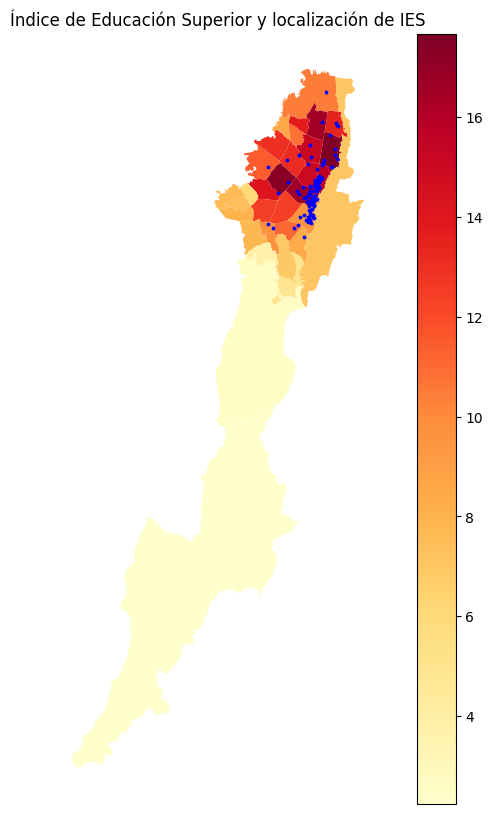

In [54]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 10))

upl.plot(
    column="indice_educacion_superior",
    cmap="YlOrRd",
    legend=True,
    ax=ax
)

hei.plot(ax=ax, color="blue", markersize=3, label="IES")

ax.set_axis_off()
plt.title("Índice de Educación Superior y localización de IES")
plt.show()

In [55]:
upl.to_file("upl.geojson", driver='GeoJSON')